In [ ]:
# Para mostrar e insertar imágenes directamente en el notebook
from IPython.display import Image

In [ ]:
import cv2 # paquete para procesamiento de imágenes
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path # Para trabajar con rutas de archivos

Para mostrar gráficas generadas por matplotlib en la misma celda se usa el comando mágico de IPython `%matplotlib inline`.

In [39]:
%matplotlib inline

In [10]:
DATA_DIR = Path.cwd().resolve() / "imagenes"
DATA_DIR

PosixPath('/mnt/d/DataAI-Fundamentos-Aplicaciones/Analitica/ciencia_datos_con_python/notebooks_ejemplos/imagenes')

In [13]:
imagen_path = DATA_DIR / "colibri.jpeg"

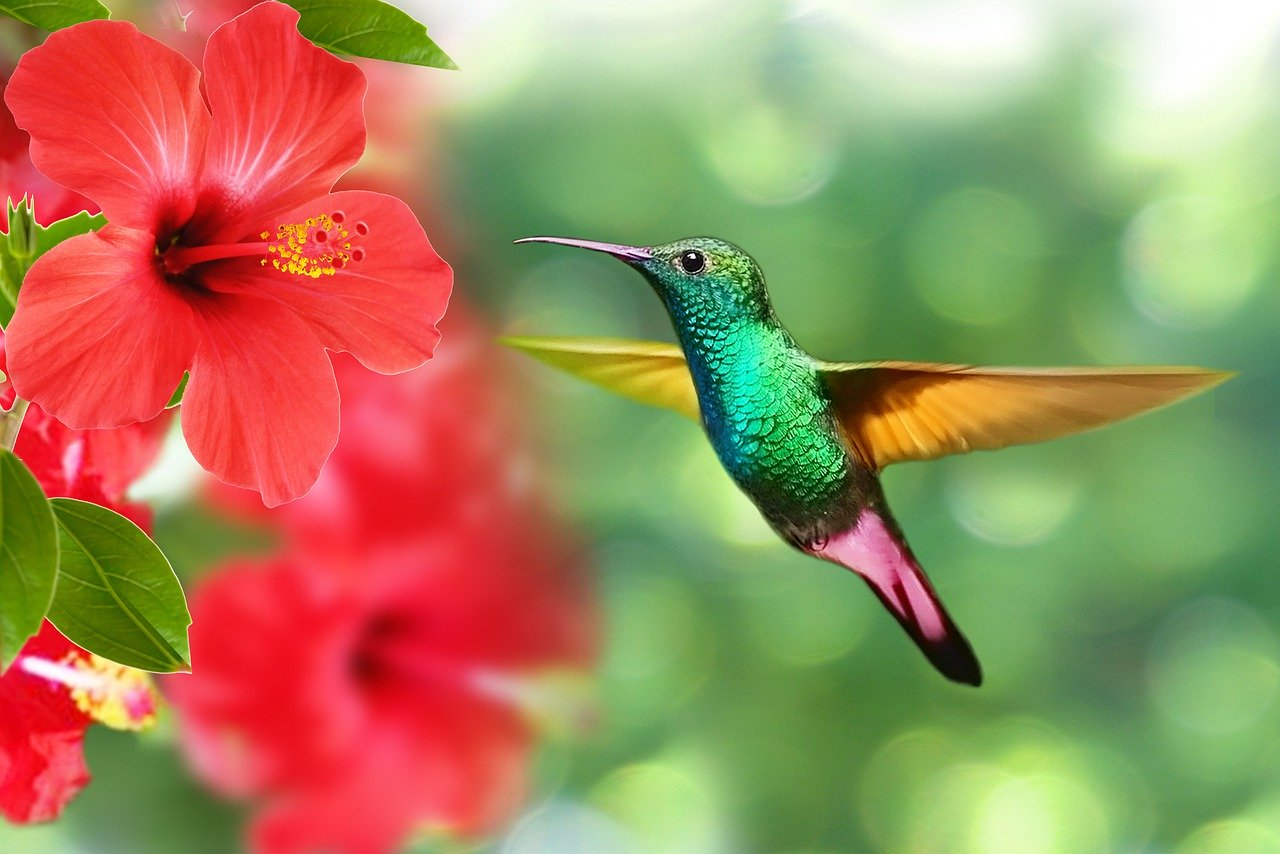

In [14]:
Image(imagen_path)

Esta imagen se puede representar en Python como un arreglo de 3 dimensiones: alto, ancho y profundo.

In [23]:
# cv2.imread lee la imagen en formato BGR (azul, verde, rojo) por defecto

img = cv2.imread(DATA_DIR / "colibri.jpeg", cv2.IMREAD_COLOR)

OpenCV trabaja con el formato BGR (blue, green, red). Originalmente, la biblioteca se diseñó para trabajar con cámaras y sistemas que entregaban datos en ese orden, y con el tiempo se consolidó esa convención en la comunidad OpenCV.

Sin embargo, bibliotecas como Matplotlib, esperan imágenes en formato RGB. Por esto, es importante reordenar los canales de colores para extraer información de manera correcta.

In [24]:
# Convertir la imagen de BGR a RGB para que se muestre correctamente con matplotlib

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [29]:
img.shape

(854, 1280, 3)

In [30]:
print("Fragmento del arreglo (4 filas x 5 columnas):\n", img[:4, :5])

Fragmento del arreglo (4 filas x 5 columnas):
 [[[ 54  89   0]
  [ 60  95   5]
  [ 62  97   7]
  [ 59  94   4]
  [ 58  94   4]]

 [[ 61  96   4]
  [ 57  92   0]
  [ 51  86   0]
  [ 50  85   0]
  [ 54  91   0]]

 [[ 55  89   0]
  [ 55  89   0]
  [ 56  91   0]
  [ 59  94   0]
  [ 60  95   1]]

 [[ 56  90   0]
  [ 54  88   0]
  [ 57  91   0]
  [ 63  99   1]
  [ 66 102   6]]]


In [31]:
# Las imágenes son arreglos o matrices de números; cada píxel tiene un valor numérico.
# Imprimir una pequeña porción del arreglo para "ver" cómo se organizan los datos:

print("Fragmento del arreglo (4 filas x 5 columnas):\n", img[:4, :5])

Fragmento del arreglo (4 filas x 5 columnas):
 [[[ 54  89   0]
  [ 60  95   5]
  [ 62  97   7]
  [ 59  94   4]
  [ 58  94   4]]

 [[ 61  96   4]
  [ 57  92   0]
  [ 51  86   0]
  [ 50  85   0]
  [ 54  91   0]]

 [[ 55  89   0]
  [ 55  89   0]
  [ 56  91   0]
  [ 59  94   0]
  [ 60  95   1]]

 [[ 56  90   0]
  [ 54  88   0]
  [ 57  91   0]
  [ 63  99   1]
  [ 66 102   6]]]


Imprimir todo el arreglo no es útil, ya que contiene muchos datos sin formato.

## Extracción de una región de interés

In [32]:
# Supongamos que queremos extraer únicamente la parte de la imagen donde aparece el colibrí.
# Seleccionamos una región mediante índices: [filas_inicial:filas_final, columnas_inicial:columnas_final]
colibri = img[180:680, 480:-30]

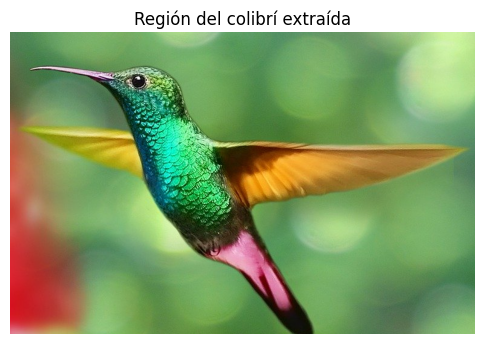

In [33]:
# Mostrar la imagen del colibrí extraído
plt.figure(figsize=(6, 4))
plt.imshow(colibri)
plt.title("Región del colibrí extraída")
plt.axis("off")
plt.show()

## Operaciones con NumPy aplicadas a la imagen

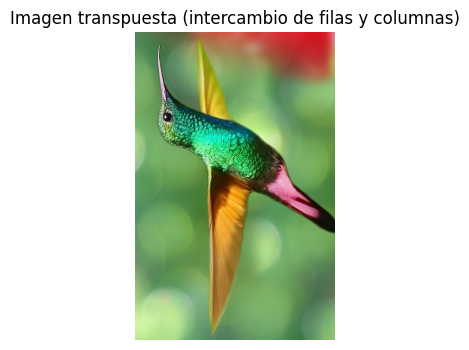

In [34]:
# a) Transponer la imagen:
# Cambiamos el orden de los ejes (filas y columnas) para ver el efecto en la visualización.
colibri_transpuesta = np.transpose(colibri, (1, 0, 2))
plt.figure(figsize=(6, 4))
plt.imshow(colibri_transpuesta)
plt.title("Imagen transpuesta (intercambio de filas y columnas)")
plt.axis("off")
plt.show()

La función np.transpose reordena los ejes del arreglo. En este caso, la imagen colibri tiene una forma típica de (filas, columnas, canales).

El parámetro (1, 0, 2) indica lo siguiente:

- 1: El primer eje (índice 0) de la nueva imagen será el eje 1 de la imagen original, es decir, las columnas.

- 0: El segundo eje (índice 1) de la nueva imagen será el eje 0 de la imagen original, es decir, las filas.

- 2: El tercer eje (índice 2) se mantiene sin cambios, por lo que los canales de color permanecen iguales.

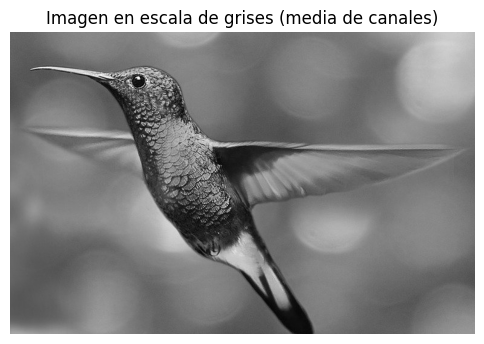

In [35]:
# b) Convertir la imagen a escala de grises:
# Calculamos la media de los tres canales de color (R, G, B) para cada píxel.
colibri_gris = np.mean(colibri, axis=2)
plt.figure(figsize=(6, 4))
plt.imshow(colibri_gris, cmap="gray")
plt.title("Imagen en escala de grises (media de canales)")
plt.axis("off")
plt.show()

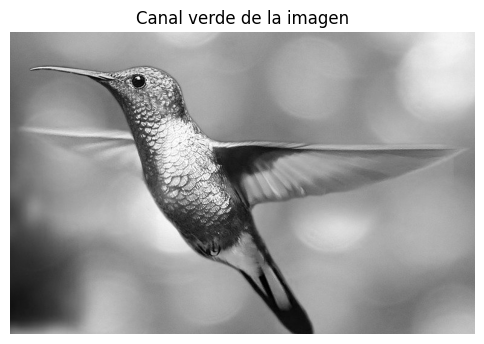

In [36]:
# c) Mostrar un solo canal de color:
# Extraemos, por ejemplo, el canal verde (índice 1) de la imagen.
colibri_canal_verde = colibri[..., 1]
plt.figure(figsize=(6, 4))
plt.imshow(colibri_canal_verde, cmap="gray")
plt.title("Canal verde de la imagen")
plt.axis("off")
plt.show()

La imagen se ve gris porque al extraer un canal, se obtiene una matriz bidimensional de valores de intensidad. Al mostrar esta matriz, Matplotlib la interpreta como una imagen en escala de frises, ya que solo tiene un valor por pixel (la intensidad) y no tiene información completa de tres canales para formar un color.

Por eso, aunque se trate del canal verde, al visualizarlo se ve como una imagen en tonos de gris, donde los valors más altos representan zonas más brillantes y los más bajos zonas más oscuras.

## Enfoque de analítica de datos

En ciencia de datos, tratamos los datos (en este caso, cada píxel de la imagen) como números
que podemos transformar, analizar y visualizar. Las operaciones que hemos realizado:

  - Acceder a partes específicas del arreglo (slicing)
  - Cambiar la estructura del arreglo (transposición)
  - Calcular estadísticas básicas (media para convertir a escala de grises)
  - Extraer información específica (un canal de color)
#
Estos conceptos son fundamentales para el análisis de cualquier tipo de dato.
Practicar con imágenes es una excelente forma de comprender cómo funcionan los arreglos en NumPy,
lo cual es una habilidad esencial en la analítica de datos.